In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from grinsted_firn_model import *

plt.style.use("aslak")

rhoi = 917
g = 9.82
secperyear = 365.25 * 24 * 60 * 60

In [ ]:
t = np.linspace(0, 2000, 777)
e1 = t * 0 + 0.001 / sec_per_year
e2 = t * 0 - e1
bdot = 0.11 * rhoi + t * 0
T = -31  # + t * 0 lets not evolve Temperature yet... (we should be able to do the Abar method here too...)

rho_surf = 327

dt = (t[1] - t[0]) * sec_per_year  # SHOULD BE CALCULATED AT EACH STEP
# outputs
dH = np.zeros_like(t)  # layer thickness  (inverted so bottom is on top)
dM = np.zeros_like(t)  # the layer mass per m2 --- e.g. mass should be "lost" if there is horiz flow divergence.
rho = np.zeros_like(t)
# todo age of layer!
for tix in range(len(t)):
    ix = len(t) - tix - 1
    # add a new layer of snow
    dM[ix] = bdot[ix] * dt / sec_per_year  #
    dH[ix] = dM[ix] / rho_surf  # TODO: remove dH from loop - not needed!
    rho[ix] = rho_surf
    if tix == 0:
        continue
    # update layers below
    sigma_zz = -np.cumsum(dM[ix:-1]) * g  # the mass of the deepest layer does not compress anything.
    a = a_fun(rho[ix + 1 :])
    nu = sigmoidal_poisson(rho[ix + 1 :])
    b = poisson_to_b(nu, a)
    # b = b_fun(rho)
    A = A_fun(T + 273.15)
    ezz = np.zeros_like(sigma_zz)
    for iz in range(len(ezz)):
        ezz[iz] = gagliardini_ezz(sigma_zz[iz], a[iz], b[iz], A, e1[ix], e2[ix])
    # what is Drho/Dt:
    # upd
    DrhoDt = -rho[ix + 1 :] * (e1[ix] + e2[ix] + ezz)  # snapshot balance equation
    dM[ix + 1 :] = dM[ix + 1 :] * np.exp(-dt * (e1[ix] + e2[ix]))  # units sec per year...
    rho[ix + 1 :] = rhoi - np.exp(np.log(rhoi - rho[ix + 1 :]) - DrhoDt * dt / (rhoi - rho[ix + 1 :]))
    # rho[ix + 1 :] = rho[ix + 1 :] + DrhoDt * dt #naive update
    dH[ix + 1 :] = dM[ix + 1 :] / rho[ix + 1 :]

    # TODO: check self consistency in updating

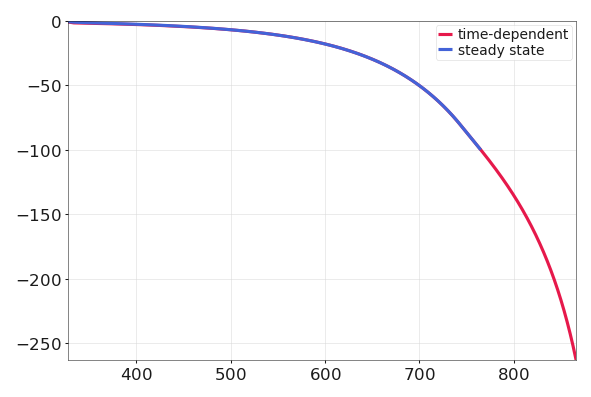

In [ ]:
z = np.cumsum(dH)


def newb_fun(rho):
    a = a_fun(rho)
    nu = sigmoidal_poisson(rho)
    return poisson_to_b(nu, a)


plt.plot(rho, -z, label="time-dependent")
z_steady, rho_steady = density_profile(T + 273.15, 30, np.mean(bdot) / sec_per_year, rho_surf, e1=np.mean(e1), e2=np.mean(e2), b_fun=newb_fun)
plt.plot(rho_steady, -z_steady, label="steady state")
plt.legend()

In [ ]:
def _expand_to_length(param, target_length):
    """Expand scalar or 1D array to target length."""
    param = np.atleast_1d(param)
    return np.broadcast_to(param, (target_length,)) if param.size == 1 else param


def nonsteadyfirnmodel(tyr=np.linspace(0, 1000), e1=0, e2=0, bdot=0.1, T_kelvin=-31, rho_surf=330, A_fun=A_fun, a_fun=a_fun, b_fun=b_fun):
    A = A_fun(T_kelvin + 273.15)

    n = len(tyr)
    e1 = _expand_to_length(e1, n)
    e2 = _expand_to_length(e2, n)
    bdot = _expand_to_length(bdot, n)
    rho_surf = _expand_to_length(rho_surf, n)

    dt = (tyr[1] - tyr[0]) * sec_per_year  # SHOULD BE CALCULATED AT EACH STEP
    # outputs
    dH = np.zeros_like(t)  # layer thickness  (inverted so bottom is on top)
    dM = np.zeros_like(t)  # the layer mass per m2 --- e.g. mass should be "lost" if there is horiz flow divergence.
    rho = np.zeros_like(t)
    # todo age of layer!
    for tix in range(len(tyr)):
        ix = len(tyr) - tix - 1
        # add a new layer of snow
        dM[ix] = bdot[ix] * dt / sec_per_year  #
        dH[ix] = dM[ix] / rho_surf[ix]  # TODO: remove dH from loop - not needed!
        rho[ix] = rho_surf[ix]
        if tix == 0:
            continue
        # update layers below
        sigma_zz = -np.cumsum(dM[ix:-1]) * g  # the mass of the deepest layer does not compress anything.
        a = a_fun(rho[ix + 1 :])
        b = b_fun(rho[ix + 1 :])
        ezz = np.zeros_like(sigma_zz)
        for iz in range(len(ezz)):
            ezz[iz] = gagliardini_ezz(sigma_zz[iz], a[iz], b[iz], A, e1[ix], e2[ix])
        # what is Drho/Dt:
        DrhoDt = -rho[ix + 1 :] * (e1[ix] + e2[ix] + ezz)  # snapshot balance equation
        dM[ix + 1 :] = dM[ix + 1 :] * np.exp(-dt * (e1[ix] + e2[ix]))  # units sec per year...
        rho[ix + 1 :] = rhoi - np.exp(np.log(rhoi - rho[ix + 1 :]) - DrhoDt * dt / (rhoi - rho[ix + 1 :]))
        dH[ix + 1 :] = dM[ix + 1 :] / rho[ix + 1 :]
    z = np.cumsum(dH) - dH / 2
    return t, z, rho, dM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
scalar = np.array([10, 5])
np.full([10], scalar)

ValueError: could not broadcast input array from shape (2,) into shape (10,)